In [1]:
!pip install ultralytics
!pip install opencv-python
!pip install mediapipe
!pip install wandb
!pip install scikit-learn

In [11]:
import wandb
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/amber/.netrc.
wandb: Currently logged in as: amberchee (amberchee-xiamen-university-malaysia) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
wandb.init(
    project="hazard_classification",
    name="efficientnet_v1"
)

NameError: name 'wandb' is not defined

In [2]:
DATASET_PATH = "/Users/amber/Desktop/hackathon/hazard_dataset"
batch_size = 32
epochs = 30
lr = 0.001

In [3]:
# Dataset Preprocessing

def get_transformed():
  train_transformed = transforms.Compose([
      transforms.Resize((224, 224)),
      transforms.RandomHorizontalFlip(p=0.5),
      transforms.RandomRotation(15),
      
      transforms.ColorJitter(
          brightness=0.2,
          contrast=0.2,
          saturation=0.2,
          hue=0.05
      ),

      transforms.ToTensor(),

      transforms.Normalize(
          mean=[0.485, 0.456, 0.406],
          std=[0.229, 0.224, 0.225]
      ) 
  ])
  
  val_transformed = transforms.Compose([
      transforms.Resize((224, 224)),
      transforms.ToTensor(),
      transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
  ])

  return train_transformed, val_transformed

In [4]:
# Load & Split Dataset

def load_datasets(data_path):
  train_t, val_t = get_transformed()

  full_dataset = datasets.ImageFolder(data_path, transform=train_t)
  class_labels = full_dataset.classes

  print("Classes: ", class_labels)
  print("Total Images: ", len(full_dataset))

  total = len(full_dataset)
  train_size = int(0.8 * total)
  val_size = int(0.1 * total)
  test_size = total - train_size - val_size

  train_ds, val_ds, test_ds = random_split(full_dataset, [train_size, val_size, test_size])

  val_ds.dataset.transform = val_t
  test_ds.dataset.transform = val_t

  train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
  val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
  test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

  return train_loader, val_loader, test_loader, class_labels


In [5]:
def build_efficientnet(num_classes, device):
  model = models.efficientnet_b0(pretrained=True)
  in_features = model.classifier[1].in_features
  model.classifier[1] = nn.Linear(in_features, num_classes) # Reduce output classes to 4
  return model

In [6]:
def train_model(model, train_loader, val_loader, device, epochs=30, lr=0.001, patience=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float("inf")
    patience_counter = 0

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(epochs):
        model.train()
        train_correct = 0
        train_total = 0
        train_loss = 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            _, preds = outputs.max(1)
            train_total += labels.size(0)
            train_correct += preds.eq(labels).sum().item()

        train_acc = train_correct / train_total
        train_loss = train_loss / len(train_loader)

        model.eval()
        val_correct = 0
        val_total = 0
        val_loss = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)

                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, preds = outputs.max(1)
                val_total += labels.size(0)
                val_correct += preds.eq(labels).sum().item()

        val_acc = val_correct / val_total
        val_loss = val_loss / len(val_loader)

        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.4f} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        wandb.log({
            "epoch": epoch+1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_acc,
            "val_acc": val_acc
        })

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            
            torch.save(model.state_dict(), "best_model.pth")
            print("Best model saved")

        else:
            patience_counter += 1
            print(f"No improvement ({patience_counter}/{patience})")

        if patience_counter >= patience:
            print(f"Early stop at epoch {epoch+1}")
            break

    return train_losses, val_losses, train_accs, val_accs       

In [7]:
def evaluate_model(
    model,
    test_loader,
    device,
    class_names,
    model_path="/Users/amber/Desktop/hackathon/disaster-readiness/ai/classification/notebook/best_model.pth"
):
    
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    criterion = nn.CrossEntropyLoss()

    total = 0
    correct = 0
    total_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            _, preds = outputs.max(1)

            total += labels.size(0)
            correct += preds.eq(labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_acc = correct / total
    test_loss = total_loss / len(test_loader)

    print(f"Test Accuracy : {test_acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))


    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.show()

    return test_acc, test_loss

In [8]:
def accuracyloss_curves(train_losses, val_losses, train_accs, val_accs):

    epochs_range = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(epochs_range, train_losses, marker="o", label="Train Loss")
    plt.plot(epochs_range, val_losses, marker="o", label="Validation Loss")
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1,2,2)
    plt.plot(epochs_range, train_accs, marker="o", label="Train Accuracy")
    plt.plot(epochs_range, val_accs, marker="o", label="Validation Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

Using Apple MPS GPU
Classes:  ['fire', 'flood', 'landslide', 'normal']
Total Images:  2110
Classes: ['fire', 'flood', 'landslide', 'normal']


/Users/amber/miniconda3/envs/tf310/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/amber/miniconda3/envs/tf310/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/30 | Train Acc: 0.8934 | Train Loss: 0.3401 | Val Loss: 0.0914 | Val Acc: 0.9621
Best model saved
Epoch 2/30 | Train Acc: 0.9591 | Train Loss: 0.1302 | Val Loss: 0.0937 | Val Acc: 0.9668
No improvement (1/5)
Epoch 3/30 | Train Acc: 0.9692 | Train Loss: 0.0941 | Val Loss: 0.0603 | Val Acc: 0.9763
Best model saved
Epoch 4/30 | Train Acc: 0.9876 | Train Loss: 0.0488 | Val Loss: 0.0529 | Val Acc: 0.9810
Best model saved
Epoch 5/30 | Train Acc: 0.9757 | Train Loss: 0.0749 | Val Loss: 0.1312 | Val Acc: 0.9573
No improvement (1/5)
Epoch 6/30 | Train Acc: 0.9870 | Train Loss: 0.0563 | Val Loss: 0.0760 | Val Acc: 0.9810
No improvement (2/5)
Epoch 7/30 | Train Acc: 0.9947 | Train Loss: 0.0278 | Val Loss: 0.0493 | Val Acc: 0.9905
Best model saved
Epoch 8/30 | Train Acc: 0.9769 | Train Loss: 0.0620 | Val Loss: 0.0772 | Val Acc: 0.9810
No improvement (1/5)
Epoch 9/30 | Train Acc: 0.9858 | Train Loss: 0.0577 | Val Loss: 0.1494 | Val Acc: 0.9384
No improvement (2/5)
Epoch 10/30 | Train Acc: 0

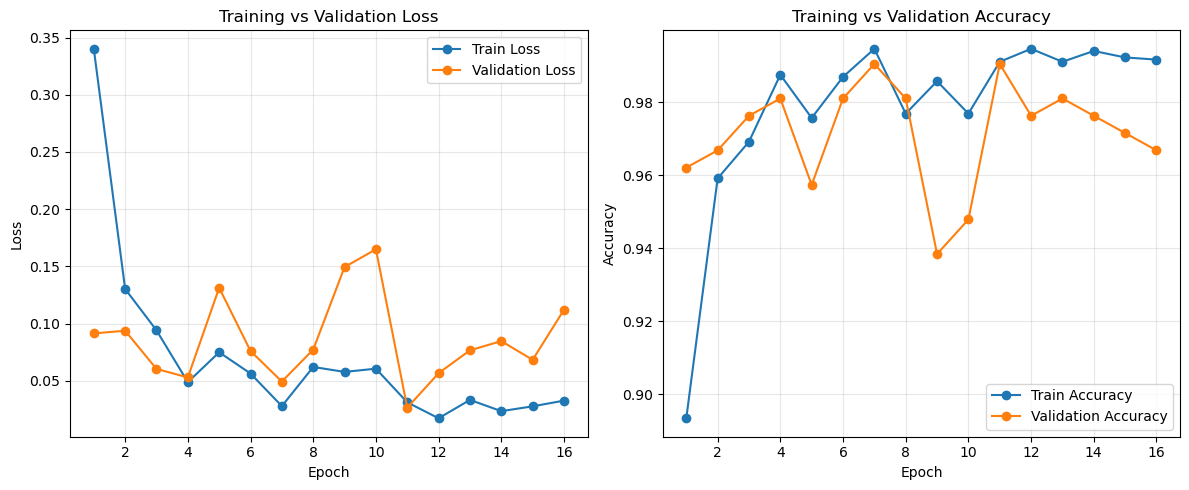

Test Accuracy : 0.9716

Classification Report:
              precision    recall  f1-score   support

        fire     0.9839    1.0000    0.9919        61
       flood     0.9630    0.9630    0.9630        54
   landslide     0.9412    0.9143    0.9275        35
      normal     0.9836    0.9836    0.9836        61

    accuracy                         0.9716       211
   macro avg     0.9679    0.9652    0.9665       211
weighted avg     0.9714    0.9716    0.9714       211



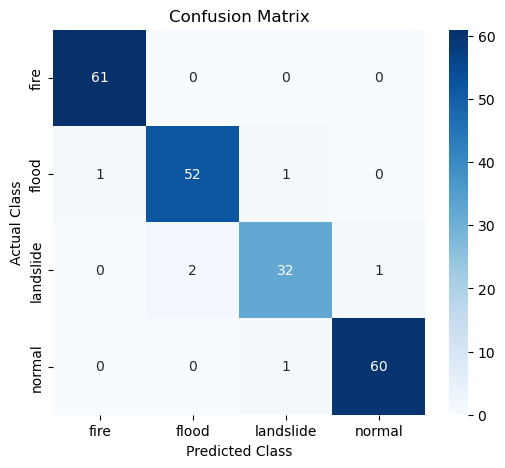

In [12]:
def main():
    wandb.init(project="hazard-classifier", name = "version1")

    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using Apple MPS GPU")

    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print("Using CUDA GPU")

    else:
        device = torch.device("cpu")
        print("Using CPU")

    train_loader, val_loader, test_loader, class_names = load_datasets(DATASET_PATH)

    print(f"Classes: {class_names}")

    model = build_efficientnet(len(class_names), device)
    model = model.to(device).float()

    train_losses, val_losses, train_accs, val_accs = train_model(
        model,
        train_loader,
        val_loader,
        device
    )

    accuracyloss_curves(train_losses, val_losses, train_accs, val_accs)

    evaluate_model(
        model,
        test_loader,
        device,
        class_names,
        model_path= "/Users/amber/Desktop/hackathon/disaster-readiness/ai/classification/notebook/best_model.pth"
    )

if __name__ == "__main__":
    main()